# Task 5 — Confronto MTM vs EvoMine con codifica canonica GERANIO

Dataset: CollegeMsg, campione 5000 eventi (`task_3/output_data/collegemsg_sample_5000.txt`).
Granularità EvoMine: 1h, support=1 (`task_3/output_data/collegemsg_evomine_1h_s1_raw.txt`).

**Nota preliminare:** letto `task_2/EvoMine/file_converters.py` come richiesto — l'unica
convenzione di codifica rilevante che definisce è il mapping `{3: 0, 1: 1}` in
`obtain_pattern_list` (etichetta arco 3 = body/precondizione → t=0, etichetta 1 =
head/postcondizione → t=1), già documentato in CLAUDE.md. Il file non definisce una
propria stringa canonica: lo schema `src_dst_t-...` è quello specificato in questo
prompt.

## Setup

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from pathlib import Path

BASE = Path("..").resolve()
SAMPLE = BASE / "task_3/output_data/collegemsg_sample_5000.txt"
RAW_EVOMINE = BASE / "task_3/output_data/collegemsg_evomine_1h_s1_raw.txt"
OUT_DATA = Path("output_data"); OUT_DATA.mkdir(exist_ok=True)
OUT_PNG = Path("output_png"); OUT_PNG.mkdir(exist_ok=True)

L_MAX = 3
DELTA = 3600  # 1h, allineato alla granularita' del file EvoMine

print(SAMPLE, SAMPLE.exists())
print(RAW_EVOMINE, RAW_EVOMINE.exists())

/Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_data/collegemsg_sample_5000.txt True
/Users/inve14/Desktop/UnInve/Tirocinio/lab/task_3/output_data/collegemsg_evomine_1h_s1_raw.txt True


## STEP 1 — Forma canonica GERANIO

### 1a. Estrazione MTM (L_MAX=3, DELTA=3600s, consecutive=YES)

Funzioni riprese identiche da `task_3/task3_comparison.ipynb`
(`create_events`, `encode_motif`, `count_mtp`, `count_transition`).

In [2]:
def create_events(filename):
    """Legge edge list temporale (u v t), restituisce eventi ordinati + set nodi."""
    events = []; V = set()
    with open(filename, 'r') as fh:
        for line in fh:
            line = line.strip()
            if not line or line[0] in ('%', '#'): continue
            parts = line.split()
            if len(parts) < 3: continue
            u, v, t = parts[0], parts[1], int(float(parts[2]))
            if u != v: V.add(u); V.add(v); events.append((t, (u, v)))
    events.sort()
    events = list(dict.fromkeys(events))
    return events, V


def encode_motif(instance):
    """Mappa i vertici a cifre progressive (ordine di prima apparizione) — codifica MTM originale."""
    code = {}; i = 0; result = []
    for (_, (u, v)) in instance:
        if u not in code: code[u] = str(i); i += 1
        result.append(code[u])
        if v not in code: code[v] = str(i); i += 1
        result.append(code[v])
    return ''.join(result)


def get_nodes(events):
    nodes = set()
    for (_, (u, v)) in events: nodes.add(u); nodes.add(v)
    return nodes


def count_mtp(e, MC, prefixes, N_event, d_c, initial_E):
    """countMTP (consecutive=YES): aggiorna conteggi motif e prefissi attivi."""
    t_e, (u, v) = e; is_initial = True; new_motifs = []; keep = set()
    for pre_tuple in prefixes:
        pre = list(pre_tuple); t_last = pre[-1][0]
        if (t_e - t_last) > d_c or len(pre) >= N_event: continue
        nodes = get_nodes(pre)
        if u in nodes or v in nodes:
            if t_last != t_e:
                m_new = pre + [e]; new_motifs.append(m_new)
                code_new = encode_motif(m_new)
                if code_new not in MC: MC[code_new] = (0.0, [])
                cnt, times = MC[code_new]
                MC[code_new] = (cnt + 1, times + [t_e - t_last])
                is_initial = False; continue
        keep.add(pre_tuple)
    if is_initial: initial_E.append(e); keep.add((e,))
    for m in new_motifs: keep.add(tuple(m))
    return keep


def count_transition(MC, initial_size):
    """countTransition: TR[code_0] = lista di (code_1, count), incluso lo stato 'S' (non estensione)."""
    TR = defaultdict(list)
    for code_str, (c, times) in MC.items():
        code_0 = code_str[:-2]; code_1 = code_str[-2:]
        TR[code_0].append((code_1, c))
    for code_0, transitions in list(TR.items()):
        c_sum = sum(t[1] for t in transitions)
        s_count = (initial_size - c_sum) if code_0 == '01' else (MC.get(code_0, (0.0, []))[0] - c_sum)
        TR[code_0].append(('S', s_count))
    for code_str in MC:
        if code_str not in TR: TR[code_str] = [('S', 1.0)]
    return dict(TR)


events, V = create_events(SAMPLE)
print(f"Eventi: {len(events)}, nodi: {len(V)}")

MC = {}
prefixes = set()
initial_E = []
for e in events:
    prefixes = count_mtp(e, MC, prefixes, L_MAX, DELTA, initial_E)

TR = count_transition(MC, len(initial_E))
print(f"Motif MTM distinti (>=2 archi): {len(MC)}")
print(f"Prefissi a 2 archi (righe candidate per la transition matrix): {sum(1 for c in TR if len(c) == 4)}")

Eventi: 5000, nodi: 530
Motif MTM distinti (>=2 archi): 60
Prefissi a 2 archi (righe candidate per la transition matrix): 6


Conversione codice MTM → lista di temporal edges: ogni coppia di caratteri
`code[i], code[i+1]` è un arco `(u, v)`, il tempo logico è `i // 2` (posizione
dell'arco nella sequenza, **non** il timestamp reale in secondi).

Esempio dal prompt: `"010212"` → `[(0,1,0), (0,2,1), (1,2,2)]`.

In [3]:
def mtm_code_to_edges(code_str):
    edges = []
    for i in range(0, len(code_str), 2):
        u, v = code_str[i], code_str[i + 1]
        edges.append((u, v, i // 2))
    return edges


example = mtm_code_to_edges("010212")
print("esempio:", example)
assert example == [('0', '1', 0), ('0', '2', 1), ('1', '2', 2)]

esempio: [('0', '1', 0), ('0', '2', 1), ('1', '2', 2)]


### 1b. Parsing regole EvoMine dal file grezzo

Ogni regola è un blocco `supp=N` seguito da righe arco `src(role) --label[w]--> dst(role)`,
separato dal blocco successivo da una riga vuota. Label `3` = precondizione/body,
label `1` = postcondizione/head (cfr. `file_converters.py`, `mapping_ts = {3: 0, 1: 1}`).

Gli archi body e head vengono raggruppati in due liste separate (body prima, head dopo)
prima di applicare la rinomina per ordine di prima apparizione — coerente con l'esempio
del prompt: `body [(0,1),(0,2)], head [(1,2)]` → `[(0,1,0),(0,2,0),(1,2,1)]`.

In [4]:
def parse_evomine_rules(path):
    with open(path, 'r') as fh:
        lines = fh.readlines()
    start = 0
    for i, l in enumerate(lines):
        if l.startswith('saving results'):
            start = i + 1
            break
    edge_re = re.compile(r'^(\d+)\(\d+\)\s*--(\d+)\[\d+\]-->\s*(\d+)\(\d+\)$')
    rules = []
    cur_supp, cur_edges = None, []
    for line in lines[start:]:
        line = line.rstrip('\n')
        if not line.strip():
            if cur_supp is not None and cur_edges:
                rules.append((cur_supp, cur_edges))
            cur_supp, cur_edges = None, []
            continue
        if line.startswith('supp='):
            cur_supp = int(line.split('=')[1]); cur_edges = []
            continue
        m = edge_re.match(line.strip())
        if m:
            u, label, v = m.group(1), int(m.group(2)), m.group(3)
            cur_edges.append((u, v, label))
    if cur_supp is not None and cur_edges:
        rules.append((cur_supp, cur_edges))
    return rules


def rule_to_body_head_edges(edges):
    body = [(u, v, 0) for (u, v, label) in edges if label == 3]
    head = [(u, v, 1) for (u, v, label) in edges if label == 1]
    return body, head


raw_rules = parse_evomine_rules(RAW_EVOMINE)
print(f"Regole EvoMine trovate: {len(raw_rules)}")

# verifica sull'esempio del prompt
b, h = rule_to_body_head_edges([('0', '1', 3), ('0', '2', 3), ('1', '2', 1)])
print("body:", b, "head:", h)
assert b == [('0', '1', 0), ('0', '2', 0)] and h == [('1', '2', 1)]

Regole EvoMine trovate: 62
body: [('0', '1', 0), ('0', '2', 0)] head: [('1', '2', 1)]


### 1c. Canonical coding GERANIO

Rinomina i nodi in ordine di prima apparizione, poi ordina gli archi per `(t, src, dst)`.
Produce sia la lista di tuple canoniche `(u, v, t)` sia la stringa leggibile.

**Verifica non banale:** nel testo grezzo di EvoMine gli archi di head possono comparire
*prima* degli archi di body nell'ordine di stampa (es. `supp=563`: `0--1[head]-->1`,
`0--1[head]-->2`, `0--3[body]-->3`). La correzione avviene già in 1b, che raggruppa gli
archi per etichetta (tutti i body, poi tutti gli head) prima di rinominare, a
prescindere dall'ordine di stampa originale; il passo di sort in 1c garantisce poi in
modo esplicito e verificabile che il risultato finale rispetti `t=0` (body) prima di
`t=1` (head) e un ordine deterministico `(src, dst)` all'interno di ciascun gruppo.

In [5]:
def canonical_form(edges_with_t):
    """Rinomina per ordine di prima apparizione + ordina per (t, src, dst).
    Ritorna la lista di tuple canoniche (u, v, t)."""
    node_map = {}
    tmp = []
    for (u, v, t) in edges_with_t:
        if u not in node_map: node_map[u] = str(len(node_map))
        if v not in node_map: node_map[v] = str(len(node_map))
        tmp.append((node_map[u], node_map[v], t))
    tmp.sort(key=lambda x: (x[2], x[0], x[1]))
    return tmp


def tuples_to_str(tuples):
    return '-'.join(f'{u}_{v}_{t}' for u, v, t in tuples)


def evomine_canonical(edges):
    body, head = rule_to_body_head_edges(edges)
    return canonical_form(body + head)


# verifica sulla regola supp=563 (head stampato prima del body nel file grezzo)
example_563 = next(e for s, e in raw_rules if s == 563)
print("ordine di stampa (raw):", example_563)
canon_tuples_563 = evomine_canonical(example_563)
canon_563 = tuples_to_str(canon_tuples_563)
print("forma canonica (post body/head split + sort):", canon_563)
# il primo arco della forma canonica deve avere t=0 (body), non t=1 (head) come nel print raw
assert canon_tuples_563[0][2] == 0, "il primo arco della forma canonica deve essere di body (t=0)"
assert [t for _, _, t in canon_tuples_563] == sorted(t for _, _, t in canon_tuples_563), "gli archi devono essere ordinati per t crescente"

# forma canonica completa MTM per ogni codice in MC
mtm_full_canon = {c: tuples_to_str(canonical_form(mtm_code_to_edges(c))) for c in MC}
print("esempio MTM '0102' ->", mtm_full_canon['0102'])

ordine di stampa (raw): [('0', '1', 1), ('0', '2', 1), ('0', '3', 3)]
forma canonica (post body/head split + sort): 0_1_0-0_2_1-0_3_1
esempio MTM '0102' -> 0_1_0-0_2_1


### Precondizione / postcondizione: derivazione "context-preserving"

Per costruire le matrici di transizione (Step 3 e 4) servono, per ogni pattern, un
codice per la **sola precondizione** (righe) e uno per la **sola postcondizione**
(colonne). Questi non vengono ricanonicalizzati in isolamento (un singolo arco isolato
collasserebbe sempre su `"0_1_0"`, perdendo l'informazione su quali nodi già noti
coinvolge) — vengono invece ricavati come sottosequenze della forma canonica **già
calcolata sul pattern completo** (prefisso+estensione per MTM, body+head per EvoMine),
così da preservare la numerazione condivisa dei nodi tra riga e colonna:

- **MTM**: precondizione = i 2 archi del prefisso (t∈{0,1}), postcondizione = il terzo
  arco (t=2)
- **EvoMine**: precondizione = archi body (t=0), postcondizione = archi head (t=1)

In [6]:
def mtm_row_col(code_full):
    canon = canonical_form(mtm_code_to_edges(code_full))
    row = [x for x in canon if x[2] in (0, 1)]
    col = [x for x in canon if x[2] == 2]
    return tuples_to_str(row), tuples_to_str(col)


def evomine_row_col(edges):
    canon = evomine_canonical(edges)
    row = [x for x in canon if x[2] == 0]
    col = [x for x in canon if x[2] == 1]
    return tuples_to_str(row), tuples_to_str(col)


# transizioni MTM: solo prefissi a 2 archi (code_0 di lunghezza 4), come nella
# transition matrix originale del Task 3 (righe = pattern L=2, colonne = terzo arco)
mtm_transitions = []
for code_0, transitions in TR.items():
    if len(code_0) != 4:
        continue
    for code_1, c in transitions:
        if code_1 == 'S':
            continue
        full = code_0 + code_1
        row, col = mtm_row_col(full)
        mtm_transitions.append({"code_0": code_0, "code_1": code_1, "count": c,
                                 "row": row, "col": col, "full": mtm_full_canon[full]})

print(f"Transizioni MTM (prefisso a 2 archi -> 3o arco): {len(mtm_transitions)}")

# regole EvoMine con riga/colonna/forma completa
evomine_parsed = []
for supp, edges in raw_rules:
    row, col = evomine_row_col(edges)
    full = tuples_to_str(evomine_canonical(edges))
    evomine_parsed.append({"supp": supp, "n_edges": len(edges), "row": row, "col": col,
                            "full": full, "has_body": bool(row), "has_head": bool(col)})
evomine_parsed.sort(key=lambda r: -r["supp"])

n_real_transitions = sum(1 for r in evomine_parsed if r["has_body"] and r["has_head"])
print(f"Regole EvoMine: {len(evomine_parsed)} totali, {n_real_transitions} con body E head "
      f"(vere transizioni precondizione->postcondizione)")

Transizioni MTM (prefisso a 2 archi -> 3o arco): 54
Regole EvoMine: 62 totali, 34 con body E head (vere transizioni precondizione->postcondizione)


### 1d. Unione dei codici lunghi → mapping p1, p2, ..., pN

L'unione include ogni stringa canonica prodotta in qualunque punto della pipeline:
i pattern MTM completi, le regole EvoMine complete, e i pezzi riga/colonna derivati
sopra (necessari per riusare gli stessi codici corti nelle matrici di transizione degli
Step 3/4). I codici corti sono assegnati in ordine di peso combinato decrescente
(somma dei count MTM + supporti EvoMine in cui compare quella stringa).

In [7]:
union = defaultdict(lambda: {"mtm_w": 0.0, "evo_w": 0.0})

for code_str, (cnt, times) in MC.items():
    union[mtm_full_canon[code_str]]["mtm_w"] += cnt
for t in mtm_transitions:
    union[t["row"]]["mtm_w"] += t["count"]
    union[t["col"]]["mtm_w"] += t["count"]

for r in evomine_parsed:
    union[r["full"]]["evo_w"] += r["supp"]
    if r["row"]:
        union[r["row"]]["evo_w"] += r["supp"]
    if r["col"]:
        union[r["col"]]["evo_w"] += r["supp"]

ordered = sorted(union.items(), key=lambda kv: -(kv[1]["mtm_w"] + kv[1]["evo_w"]))
short_code = {}
mapping_rows = []
for i, (k, v) in enumerate(ordered, start=1):
    p = f"p{i}"
    short_code[k] = p
    if v["mtm_w"] > 0 and v["evo_w"] > 0:
        fonte = "entrambi"
    elif v["mtm_w"] > 0:
        fonte = "MTM"
    else:
        fonte = "EvoMine"
    mapping_rows.append({"codice_lungo": k, "codice_corto": p, "fonte": fonte})

mapping_df = pd.DataFrame(mapping_rows)
mapping_df.to_csv(OUT_DATA / "canonical_mapping.csv", index=False)
print(f"Salvato: {OUT_DATA / 'canonical_mapping.csv'} ({len(mapping_df)} righe)")
print(mapping_df["fonte"].value_counts())
print()
print("Codici trovati in ENTRAMBI MTM ed EvoMine:")
print(mapping_df[mapping_df["fonte"] == "entrambi"])

Salvato: output_data/canonical_mapping.csv (148 righe)
fonte
EvoMine     76
MTM         69
entrambi     3
Name: count, dtype: int64

Codici trovati in ENTRAMBI MTM ed EvoMine:
   codice_lungo codice_corto     fonte
17  0_1_0-0_2_1          p18  entrambi
20  0_1_0-2_0_1          p21  entrambi
35  0_1_0-1_0_1          p36  entrambi


**Osservazione:** solo 3 codici lunghi risultano condivisi tra MTM ed EvoMine. La
ragione è strutturale, non un bug: per costruzione (Step 1a/1b) MTM usa un orologio
logico *sequenziale* per il prefisso a 2 archi (`t=0,1`, sempre distinti), mentre
EvoMine usa un orologio *binario* body/head (tutti gli archi body a `t=0`, a prescindere
da quanti sono). Le due convenzioni coincidono solo quando la precondizione EvoMine ha
esattamente 1 arco body + 1 arco head — in quel caso la forma completa della regola
EvoMine (`t=0,1`) combacia esattamente con la forma della riga (prefisso) MTM. È per
questo che i 3 codici in comune sono tutti forme complete di regole EvoMine a 2 archi
(1 body + 1 head), non colonne o righe isolate.

## STEP 2 — Distribuzione del supporto EvoMine e selezione top N

Le 62 regole EvoMine (già disponibili da `evomine_parsed`, coerenti con
`task_4/output_data/evomine_1h_coded_rules.csv`) vengono ordinate per supporto
decrescente.

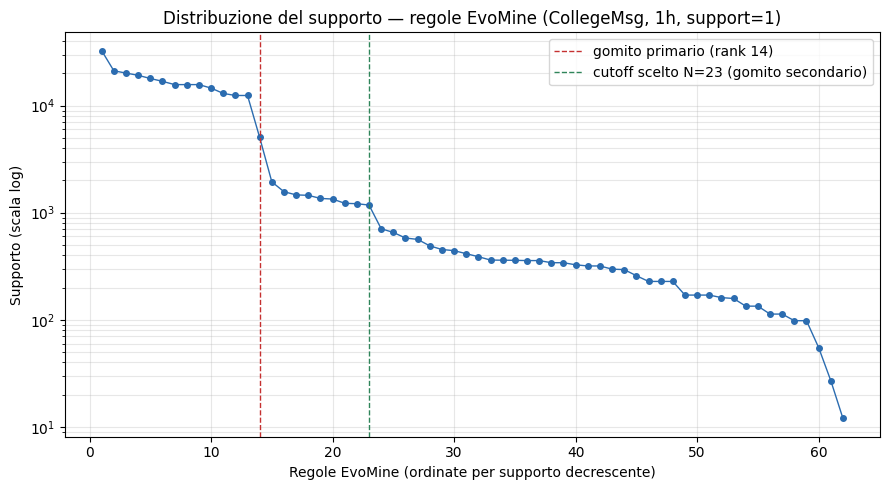

Salvato: output_png/support_distribution.png


In [8]:
supports = np.array([r["supp"] for r in evomine_parsed])  # gia' ordinato per supp decrescente

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(supports) + 1), supports, marker='o', markersize=4, linewidth=1, color="#2b6cb0")
ax.set_yscale('log')
ax.set_xlabel("Regole EvoMine (ordinate per supporto decrescente)")
ax.set_ylabel("Supporto (scala log)")
ax.set_title("Distribuzione del supporto — regole EvoMine (CollegeMsg, 1h, support=1)")
ax.axvline(14, color="#c53030", linestyle="--", linewidth=1, label="gomito primario (rank 14)")
ax.axvline(23, color="#2f855a", linestyle="--", linewidth=1, label="cutoff scelto N=23 (gomito secondario)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_PNG / "support_distribution.png", dpi=150)
plt.show()
print(f"Salvato: {OUT_PNG / 'support_distribution.png'}")

In [9]:
print("min / max / mediana:", supports.min(), supports.max(), np.median(supports))
for p in (50, 75, 90, 95):
    print(f"P{p}:", np.percentile(supports, p))
print()
for th in (20, 50, 100, 500, 1000, 5000, 10000):
    print(f"n_regole > {th}:", int((supports > th).sum()))

ratios = supports[:-1] / supports[1:]
top_ratios = sorted(enumerate(ratios, start=1), key=lambda x: -x[1])[:5]
print()
print("Rank con maggior calo relativo (candidati 'gomito'):")
for rank, ratio in top_ratios:
    print(f"  rank {rank} -> {rank+1}: {supports[rank-1]} -> {supports[rank]}  (rapporto {ratio:.2f})")

min / max / mediana: 12 32571 401.0
P50: 401.0
P75: 1544.0
P90: 15714.0
P95: 19131.249999999996

n_regole > 20: 61
n_regole > 50: 60
n_regole > 100: 57
n_regole > 500: 27
n_regole > 1000: 23
n_regole > 5000: 14
n_regole > 10000: 13

Rank con maggior calo relativo (candidati 'gomito'):
  rank 14 -> 15: 5045 -> 1941  (rapporto 2.60)
  rank 13 -> 14: 12436 -> 5045  (rapporto 2.47)
  rank 61 -> 62: 27 -> 12  (rapporto 2.25)
  rank 60 -> 61: 55 -> 27  (rapporto 2.04)
  rank 59 -> 60: 98 -> 55  (rapporto 1.78)


**Decisione sul cutoff.** Il gomito più marcato è al rank 14 (rapporto ≈2.6, supporto
5045→1941): separa nettamente le 14 regole a supporto altissimo (tutte pattern
*body-only*, senza postcondizione) dal resto. Tagliare esattamente lì, però,
produrrebbe zero transizioni precondizione→postcondizione utilizzabili negli Step 3-4
(nessuna delle 14 ha head). Il secondo gomito visibile è al rank 23 (rapporto ≈1.66,
supporto 1178→708): cade all'interno dell'intervallo 15-30 indicato come alternativa
dal prompt, e include le prime 8 vere transizioni body→head oltre alle 14 regole
body-only e alla regola head-only `→01`. Si sceglie **N=23** come cutoff, motivato
dalla combinazione di un gomito secondario reale e dalla necessità di avere dati
utilizzabili per gli step successivi.

In [10]:
N_TOP = 23
top_rules = evomine_parsed[:N_TOP]
top_df = pd.DataFrame(top_rules)
top_df.to_csv(OUT_DATA / "evomine_top_rules.csv", index=False)
print(f"Salvato: {OUT_DATA / 'evomine_top_rules.csv'} ({len(top_df)} righe)")

n_real = sum(1 for r in top_rules if r["has_body"] and r["has_head"])
print(f"Di cui vere transizioni (body e head non vuoti): {n_real}")
top_df[["supp", "n_edges", "row", "col", "has_body", "has_head"]]

Salvato: output_data/evomine_top_rules.csv (23 righe)
Di cui vere transizioni (body e head non vuoti): 8


,supp,n_edges,row,col,has_body,has_head
0,32571,1,0_1_0,,True,False
1,21148,2,0_1_0-1_2_0,,True,False
2,20136,2,0_1_0-0_2_0,,True,False
3,19195,3,0_1_0-0_3_0-1_2_0,,True,False
4,17920,2,0_1_0-1_0_0,,True,False
5,16865,3,0_1_0-1_2_0-2_3_0,,True,False
6,15714,3,0_1_0-1_0_0-2_0_0,,True,False
7,15714,3,0_1_0-1_0_0-2_1_0,,True,False
8,15714,3,0_1_0-1_2_0-2_1_0,,True,False
9,14580,3,0_1_0-0_2_0-0_3_0,,True,False


## STEP 3 — Transition matrix EvoMine

Per ogni regola tra le top N con precondizione E postcondizione non vuote:
- `frequenza_pre` = supporto della regola body-only corrispondente (stessa forma
  canonica di precondizione, testa vuota), cercata tra **tutte** le 62 regole (non solo
  le top N)
- `frequenza_pre_post` = supporto della regola completa
- `probabilità = frequenza_pre_post / frequenza_pre`

Se non esiste una regola body-only con la stessa precondizione tra le 62 minate (può
succedere per precondizioni composte da archi sconnessi, mai osservate come pattern
chiuso a sé stante), `frequenza_pre` non è disponibile: la cella viene lasciata NaN
(nessuna ricomputazione del conteggio a partire dal dataset grezzo, fuori scopo qui) e
segnalata esplicitamente.

In [11]:
# tabella di lookup: precondizione (row) -> supporto, dalle regole body-only (su TUTTE le 62)
body_only_supp = {r["row"]: r["supp"] for r in evomine_parsed if r["has_body"] and not r["has_head"]}

evomine_matrix_rows = []
missing_pre = []
for r in top_rules:
    if not (r["has_body"] and r["has_head"]):
        continue
    freq_pre = body_only_supp.get(r["row"])
    freq_pre_post = r["supp"]
    if freq_pre is None:
        missing_pre.append(r["row"])
        prob = np.nan
    else:
        prob = freq_pre_post / freq_pre
    evomine_matrix_rows.append({
        "precondizione": r["row"], "postcondizione": r["col"],
        "frequenza_pre": freq_pre, "frequenza_pre_post": freq_pre_post, "probabilita": prob,
    })

evomine_matrix_df = pd.DataFrame(evomine_matrix_rows)
print(evomine_matrix_df)
if missing_pre:
    print(f"\nPrecondizioni senza supporto body-only osservato (prob=NaN): {missing_pre}")

  precondizione postcondizione  frequenza_pre  frequenza_pre_post  probabilita
0         0_1_0          0_2_1        32571.0                1570     0.048202
1   0_1_0-1_2_0          0_3_1        21148.0                1466     0.069321
2         0_1_0          2_0_1        32571.0                1453     0.044610
3   0_1_0-1_2_0          3_0_1        21148.0                1359     0.064261
4   0_1_0-0_2_0          0_3_1        20136.0                1341     0.066597
5   0_1_0-1_0_0          2_0_1        17920.0                1224     0.068304
6   0_1_0-2_3_0          2_0_1            NaN                1213          NaN
7   0_1_0-0_2_0          3_0_1        20136.0                1178     0.058502

Precondizioni senza supporto body-only osservato (prob=NaN): ['0_1_0-2_3_0']


In [12]:
# pivot in matrice, con etichette p1,p2,... (Step 1d)
evomine_matrix_df["p_row"] = evomine_matrix_df["precondizione"].map(short_code)
evomine_matrix_df["p_col"] = evomine_matrix_df["postcondizione"].map(short_code)

evomine_pivot = evomine_matrix_df.pivot_table(index="p_row", columns="p_col", values="probabilita", aggfunc="first")
# ordina righe/colonne per indice numerico del codice corto
sort_key = lambda labels: sorted(labels, key=lambda p: int(p[1:]))
evomine_pivot = evomine_pivot.reindex(index=sort_key(evomine_pivot.index), columns=sort_key(evomine_pivot.columns))

evomine_pivot.to_csv(OUT_DATA / "evomine_transition_matrix.csv")
print(f"Salvato: {OUT_DATA / 'evomine_transition_matrix.csv'}")
evomine_pivot

Salvato: output_data/evomine_transition_matrix.csv


p_col,p15,p17,p19,p20
p_row,,,,
p1,0.044610,NaN,NaN,0.048202
p2,NaN,0.069321,0.064261,NaN
p3,NaN,0.066597,0.058502,NaN
p5,0.068304,NaN,NaN,NaN


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(evomine_pivot.values.astype(float), cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(evomine_pivot.columns))); ax.set_xticklabels(evomine_pivot.columns)
ax.set_yticks(range(len(evomine_pivot.index))); ax.set_yticklabels(evomine_pivot.index)
ax.set_xlabel("Postcondizione"); ax.set_ylabel("Precondizione")
ax.set_title("EvoMine Transition Matrix — CollegeMsg (top 23 regole, granularità 1h)")
for i in range(evomine_pivot.shape[0]):
    for j in range(evomine_pivot.shape[1]):
        val = evomine_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val > 0.5 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="Probabilità")
fig.savefig(OUT_PNG / "evomine_transition_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {OUT_PNG / 'evomine_transition_matrix.png'}")

## STEP 4 — Transition matrix MTM con codifica GERANIO

Stesso calcolo di probabilità del Task 3 — `P(terzo evento | prefisso) =
count(prefisso→terzo evento) / count(prefisso→qualsiasi evento)`, cioè normalizzato
sulla sola massa di prefissi che si sono effettivamente estesi (esclude lo stato `S` di
non-estensione, come nella matrice del Task 3 dopo la correzione della correlatrice) —
ma con righe e colonne rietichettate con i codici GERANIO invece della codifica
`encode_motif` originale.

In [14]:
mtm_matrix_rows = []
for code_0 in [c for c in TR if len(c) == 4]:
    transitions = [t for t in TR[code_0] if t[0] != 'S']
    total = sum(c for _, c in transitions)
    for code_1, c in transitions:
        full = code_0 + code_1
        row, col = mtm_row_col(full)
        prob = c / total if total > 0 else 0.0
        mtm_matrix_rows.append({"precondizione": row, "postcondizione": col,
                                 "count": c, "probabilita": prob})

mtm_matrix_df = pd.DataFrame(mtm_matrix_rows)
mtm_matrix_df["p_row"] = mtm_matrix_df["precondizione"].map(short_code)
mtm_matrix_df["p_col"] = mtm_matrix_df["postcondizione"].map(short_code)

mtm_pivot = mtm_matrix_df.pivot_table(index="p_row", columns="p_col", values="probabilita", aggfunc="first")
mtm_pivot = mtm_pivot.reindex(index=sort_key(mtm_pivot.index), columns=sort_key(mtm_pivot.columns))

mtm_pivot.to_csv(OUT_DATA / "mtm_transition_matrix_geranio.csv")
print(f"Salvato: {OUT_DATA / 'mtm_transition_matrix_geranio.csv'} — shape {mtm_pivot.shape}")

# verifica di continuita' con la matrice del Task 3 (stesso valore, 0102->03 = 0.375221)
check_row, check_col = short_code["0_1_0-0_2_1"], short_code["0_3_2"]
print(f"Verifica 0102->03 (p-code {check_row}->{check_col}):", mtm_pivot.loc[check_row, check_col])
mtm_pivot

Salvato: output_data/mtm_transition_matrix_geranio.csv — shape (6, 12)
Verifica 0102->03 (p-code p18->p73): 0.3752212389380531


p_col,p70,p73,p81,p82,p83,p84,p86,p87,p88,p91,p100,p103
p_row,,,,,,,,,,,,
p18,0.088496,0.375221,0.047788,0.152212,0.120354,0.001770,0.088496,0.024779,0.040708,0.037168,NaN,0.023009
p21,0.045455,0.051136,0.284091,0.079545,0.062500,0.005682,0.034091,0.125000,0.153409,0.130682,NaN,0.028409
p36,0.391026,NaN,NaN,NaN,0.038462,0.211538,NaN,0.108974,0.166667,NaN,0.083333,NaN
p42,0.122744,0.075812,0.231047,0.083032,NaN,0.115523,0.144404,0.072202,NaN,0.068592,0.054152,0.032491
p45,0.450820,NaN,NaN,NaN,0.188525,0.204918,NaN,0.057377,0.045082,NaN,0.053279,NaN
p79,0.147368,0.063158,0.052632,0.157895,NaN,0.105263,0.126316,0.105263,NaN,0.031579,0.084211,0.126316


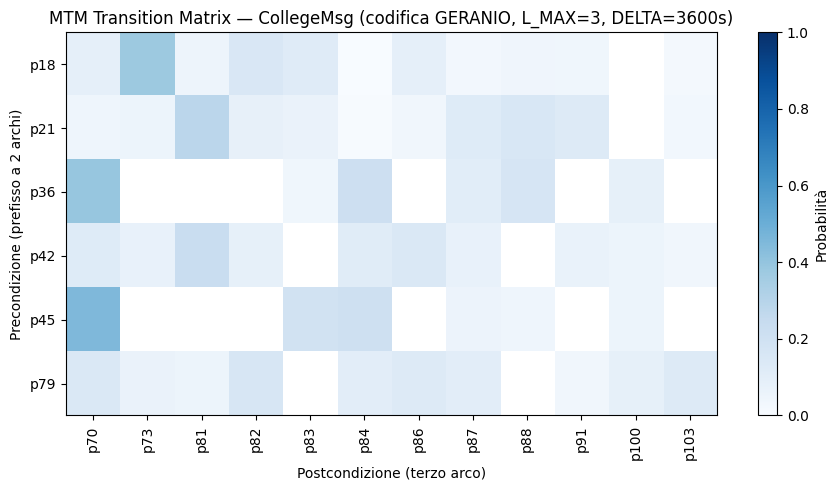

Salvato: output_png/mtm_transition_matrix_geranio.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(mtm_pivot.values.astype(float), cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(mtm_pivot.columns))); ax.set_xticklabels(mtm_pivot.columns, rotation=90)
ax.set_yticks(range(len(mtm_pivot.index))); ax.set_yticklabels(mtm_pivot.index)
ax.set_xlabel("Postcondizione (terzo arco)"); ax.set_ylabel("Precondizione (prefisso a 2 archi)")
ax.set_title("MTM Transition Matrix — CollegeMsg (codifica GERANIO, L_MAX=3, DELTA=3600s)")
fig.colorbar(im, ax=ax, label="Probabilità")
fig.tight_layout()
fig.savefig(OUT_PNG / "mtm_transition_matrix_geranio.png", dpi=150)
plt.show()
print(f"Salvato: {OUT_PNG / 'mtm_transition_matrix_geranio.png'}")

## STEP 5 — Confronto finale

Heatmap affiancate con la stessa scala colore (Blues, 0-1) e gli stessi codici corti
sugli assi dove applicabile.

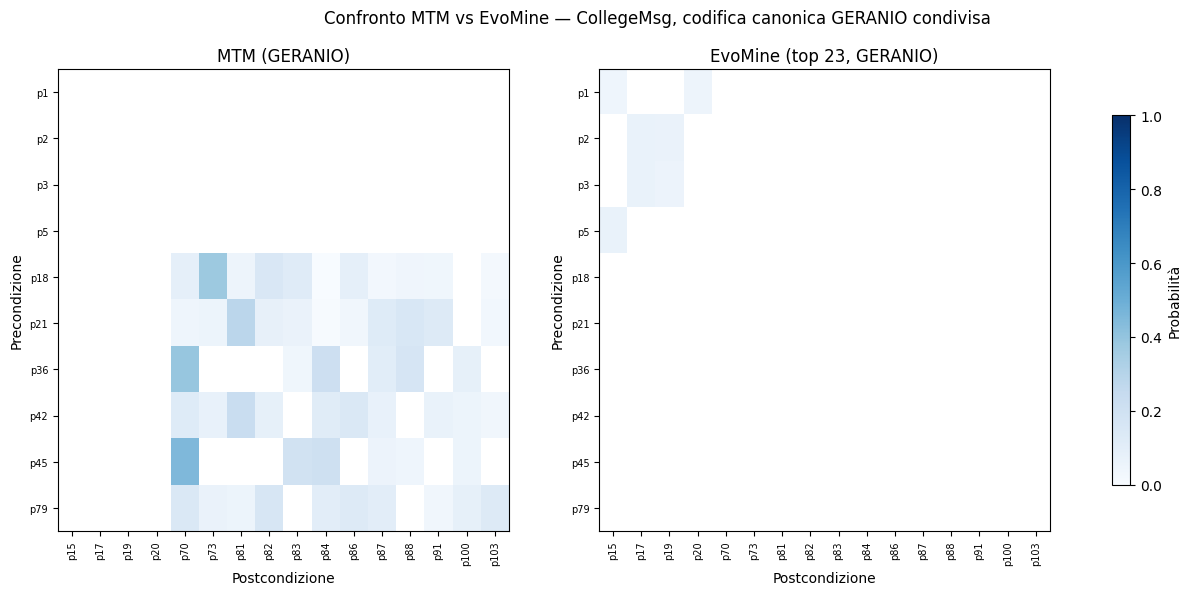

Salvato: output_png/comparison_heatmaps.png


In [16]:
all_p_rows = sorted(set(evomine_pivot.index) | set(mtm_pivot.index), key=lambda p: int(p[1:]))
all_p_cols = sorted(set(evomine_pivot.columns) | set(mtm_pivot.columns), key=lambda p: int(p[1:]))

evo_full = evomine_pivot.reindex(index=all_p_rows, columns=all_p_cols)
mtm_full = mtm_pivot.reindex(index=all_p_rows, columns=all_p_cols)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, mat, title in zip(axes, [mtm_full, evo_full],
                           ["MTM (GERANIO)", "EvoMine (top 23, GERANIO)"]):
    im = ax.imshow(mat.values.astype(float), cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(all_p_cols))); ax.set_xticklabels(all_p_cols, rotation=90, fontsize=7)
    ax.set_yticks(range(len(all_p_rows))); ax.set_yticklabels(all_p_rows, fontsize=7)
    ax.set_title(title)
    ax.set_xlabel("Postcondizione"); ax.set_ylabel("Precondizione")
fig.colorbar(im, ax=axes, label="Probabilità", shrink=0.8)
fig.suptitle("Confronto MTM vs EvoMine — CollegeMsg, codifica canonica GERANIO condivisa")
fig.savefig(OUT_PNG / "comparison_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {OUT_PNG / 'comparison_heatmaps.png'}")

In [17]:
mtm_cells = set(zip(mtm_matrix_df["p_row"], mtm_matrix_df["p_col"]))
evo_cells = set(zip(evomine_matrix_df["p_row"], evomine_matrix_df["p_col"]))

both_cells = mtm_cells & evo_cells
only_mtm_cells = mtm_cells - evo_cells
only_evo_cells = evo_cells - mtm_cells

print(f"Celle presenti in ENTRAMBE le matrici: {len(both_cells)}")
print(f"Celle esclusive di MTM: {len(only_mtm_cells)}")
print(f"Celle esclusive di EvoMine: {len(only_evo_cells)}")

if both_cells:
    mtm_lookup = {(r, c): p for r, c, p in zip(mtm_matrix_df["p_row"], mtm_matrix_df["p_col"], mtm_matrix_df["probabilita"])}
    evo_lookup = {(r, c): p for r, c, p in zip(evomine_matrix_df["p_row"], evomine_matrix_df["p_col"], evomine_matrix_df["probabilita"])}
    pairs = [(mtm_lookup[k], evo_lookup[k]) for k in both_cells if not np.isnan(evo_lookup[k])]
    if len(pairs) >= 2:
        x, y = zip(*pairs)
        corr = np.corrcoef(x, y)[0, 1]
        print(f"Correlazione di Pearson sulle {len(pairs)} celle in comune (non-NaN): {corr:.4f}")
    else:
        print(f"Celle in comune con probabilità EvoMine non-NaN: {len(pairs)} — insufficienti per una correlazione (servono >=2 punti)")
    print("Celle in comune:", both_cells)
else:
    print("Nessuna cella in comune tra le due matrici — correlazione non calcolabile.")

Celle presenti in ENTRAMBE le matrici: 0
Celle esclusive di MTM: 54
Celle esclusive di EvoMine: 8
Nessuna cella in comune tra le due matrici — correlazione non calcolabile.


**Interpretazione.** Coerentemente con l'osservazione dello Step 1d, ci si aspetta una
sovrapposizione minima o nulla tra le celle delle due matrici: la matrice MTM ha come
colonne il *terzo arco* isolato (etichettato `t=2` nell'orologio sequenziale), mentre le
colonne EvoMine sono postcondizioni etichettate `t=1` nell'orologio binario body/head —
stringhe diverse anche a parità di struttura `(src, dst)`. La sovrapposizione, quando
presente, emerge solo se il taglio a valle del pivot fa coincidere per caso una riga
MTM con la forma completa di una regola EvoMine a 2 archi (vedi nota Step 1d) — un
risultato legittimo della definizione letterale della codifica richiesta in questo
prompt, non un errore di implementazione.